https://github.com/descartes-underwriting/data-scientist-auto-test

---------------------------------------------------------------------------------------------------------------
<h1 style="color: darkblue; font-size: 36px;">DATA SCIENCE PROJECT</h1>

*The main steps for a data science project are the following*
1) import the dataset (or datasets) with which you'll need to work
2) explore it, in terms of data types, columns names ecc. There could be some transformations that need to be done
3) make some stats and EDA
4) see correlations between variables and consider to delete some of them if too much correlated with other features
5) study the missing values: are they too many? How are they distributed? Which is the percentage of them within the different columns? Take actions if needed (aka delete records or columns or impute missing values)
6) if your following model doesn't get along with categorical variables, let's change them into dummy ones
7) now the hard work (even if the previous one has not been so easy): choose a model to apply to your data, depending on the target variable(s) that you need to predict and based on the characteristics of your dataframe. Understand if it is a classification problem or a regression one, or a time series study ecc
8) implement the model
9) evaluate it
10) consider to fine tune your model or even change it and repeat steps 7-8-9-10 until you're not sufficiently satisfied
11) write down documentation on what, why and how you applied from theory and practice
12) deploy it, maintain it and hope for the best

---------------------------------------------------------------------------------------------------------------
**STEP 1: IMPORT LIBRARIES AND DATAFRAME**

In [1]:
#let's start importing the first libraries we'll need to use
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
#read the csv and see at least the very first rows to get an idea of it
auto = pd.read_csv('train_auto.csv')
auto.head()

,INDEX,TARGET_FLAG,TARGET_AMT,KIDSDRIV,AGE,HOMEKIDS,YOJ,INCOME,PARENT1,HOME_VAL,...,BLUEBOOK,TIF,CAR_TYPE,RED_CAR,OLDCLAIM,CLM_FREQ,REVOKED,MVR_PTS,CAR_AGE,URBANICITY
0,1,0,0.0,0,60.0,0,11.0,"$67,349",No,$0,...,"$14,230",11,Minivan,yes,"$4,461",2,No,3,18.0,Highly Urban/ Urban
1,2,0,0.0,0,43.0,0,11.0,"$91,449",No,"$257,252",...,"$14,940",1,Minivan,yes,$0,0,No,0,1.0,Highly Urban/ Urban
2,4,0,0.0,0,35.0,1,10.0,"$16,039",No,"$124,191",...,"$4,010",4,z_SUV,no,"$38,690",2,No,3,10.0,Highly Urban/ Urban
3,5,0,0.0,0,51.0,0,14.0,NaN,No,"$306,251",...,"$15,440",7,Minivan,yes,$0,0,No,0,6.0,Highly Urban/ Urban
4,6,0,0.0,0,50.0,0,NaN,"$114,986",No,"$243,925",...,"$18,000",1,z_SUV,no,"$19,217",2,Yes,3,17.0,Highly Urban/ Urban


---------------------------------------------------------------------------------------------------------------
**STEP 2: EXPLORATION OF DTYPES AND TRANSFORMATIONS TO BE DONE**

In [3]:
#there are some columns which are $ values (maybe they're catalogued as objects and not numeric). We can check this and then transform them into numbers
auto.dtypes

INDEX            int64
TARGET_FLAG      int64
TARGET_AMT     float64
KIDSDRIV         int64
AGE            float64
HOMEKIDS         int64
YOJ            float64
INCOME          object
PARENT1         object
HOME_VAL        object
MSTATUS         object
SEX             object
EDUCATION       object
JOB             object
TRAVTIME         int64
CAR_USE         object
BLUEBOOK        object
TIF              int64
CAR_TYPE        object
RED_CAR         object
OLDCLAIM        object
CLM_FREQ         int64
REVOKED         object
MVR_PTS          int64
CAR_AGE        float64
URBANICITY      object
dtype: object

In [4]:
#we want to use the "amount" columns as numbers, so we need to transform them.
#If they're missing values nothing to be done, if not it's necessary to take off the $ symbol and make them numbers instead of strings
auto_new = auto[['INCOME', 'HOME_VAL', 'BLUEBOOK', 'OLDCLAIM']].applymap(
    lambda x: np.nan if pd.isna(x) else pd.to_numeric(str(x).replace('$', '').replace(',', '')))
auto_new.head()

,INCOME,HOME_VAL,BLUEBOOK,OLDCLAIM
0,67349.0,0.0,14230,4461
1,91449.0,257252.0,14940,0
2,16039.0,124191.0,4010,38690
3,NaN,306251.0,15440,0
4,114986.0,243925.0,18000,19217


In [5]:
#let's replace the original columns with the transformed ones
auto[['INCOME', 'HOME_VAL', 'BLUEBOOK', 'OLDCLAIM']] = auto_new
auto.head()

,INDEX,TARGET_FLAG,TARGET_AMT,KIDSDRIV,AGE,HOMEKIDS,YOJ,INCOME,PARENT1,HOME_VAL,...,BLUEBOOK,TIF,CAR_TYPE,RED_CAR,OLDCLAIM,CLM_FREQ,REVOKED,MVR_PTS,CAR_AGE,URBANICITY
0,1,0,0.0,0,60.0,0,11.0,67349.0,No,0.0,...,14230,11,Minivan,yes,4461,2,No,3,18.0,Highly Urban/ Urban
1,2,0,0.0,0,43.0,0,11.0,91449.0,No,257252.0,...,14940,1,Minivan,yes,0,0,No,0,1.0,Highly Urban/ Urban
2,4,0,0.0,0,35.0,1,10.0,16039.0,No,124191.0,...,4010,4,z_SUV,no,38690,2,No,3,10.0,Highly Urban/ Urban
3,5,0,0.0,0,51.0,0,14.0,NaN,No,306251.0,...,15440,7,Minivan,yes,0,0,No,0,6.0,Highly Urban/ Urban
4,6,0,0.0,0,50.0,0,NaN,114986.0,No,243925.0,...,18000,1,z_SUV,no,19217,2,Yes,3,17.0,Highly Urban/ Urban


In [6]:
#let's verify if they're in the right data type now
auto.dtypes

INDEX            int64
TARGET_FLAG      int64
TARGET_AMT     float64
KIDSDRIV         int64
AGE            float64
HOMEKIDS         int64
YOJ            float64
INCOME         float64
PARENT1         object
HOME_VAL       float64
MSTATUS         object
SEX             object
EDUCATION       object
JOB             object
TRAVTIME         int64
CAR_USE         object
BLUEBOOK         int64
TIF              int64
CAR_TYPE        object
RED_CAR         object
OLDCLAIM         int64
CLM_FREQ         int64
REVOKED         object
MVR_PTS          int64
CAR_AGE        float64
URBANICITY      object
dtype: object

Now we have transformed the $values from objects to float. In this way we'll be able to predict correctly the TARGET_AMT.

---------------------------------------------------------------------------------------------------------------
**STEP 3: EDA**

In [7]:
#let's see some statistics (for the numeric variables)
auto.describe()

,INDEX,TARGET_FLAG,TARGET_AMT,KIDSDRIV,AGE,HOMEKIDS,YOJ,INCOME,HOME_VAL,TRAVTIME,BLUEBOOK,TIF,OLDCLAIM,CLM_FREQ,MVR_PTS,CAR_AGE
count,8161.000000,8161.000000,8161.000000,8161.000000,8155.000000,8161.000000,7707.000000,7716.000000,7697.000000,8161.000000,8161.000000,8161.000000,8161.000000,8161.000000,8161.000000,7651.000000
mean,5151.867663,0.263816,1504.324648,0.171057,44.790313,0.721235,10.499286,61898.094609,154867.289723,33.485725,15709.899522,5.351305,4037.076216,0.798554,1.695503,8.328323
std,2978.893962,0.440728,4704.026930,0.511534,8.627589,1.116323,4.092474,47572.682808,129123.774574,15.908333,8419.734075,4.146635,8777.139104,1.158453,2.147112,5.700742
min,1.000000,0.000000,0.000000,0.000000,16.000000,0.000000,0.000000,0.000000,0.000000,5.000000,1500.000000,1.000000,0.000000,0.000000,0.000000,-3.000000
25%,2559.000000,0.000000,0.000000,0.000000,39.000000,0.000000,9.000000,28097.000000,0.000000,22.000000,9280.000000,1.000000,0.000000,0.000000,0.000000,1.000000
50%,5133.000000,0.000000,0.000000,0.000000,45.000000,0.000000,11.000000,54028.000000,161160.000000,33.000000,14440.000000,4.000000,0.000000,0.000000,1.000000,8.000000
75%,7745.000000,1.000000,1036.000000,0.000000,51.000000,1.000000,13.000000,85986.000000,238724.000000,44.000000,20850.000000,7.000000,4636.000000,2.000000,3.000000,12.000000
max,10302.000000,1.000000,107586.136160,4.000000,81.000000,5.000000,23.000000,367030.000000,885282.000000,142.000000,69740.000000,25.000000,57037.000000,5.000000,13.000000,28.000000


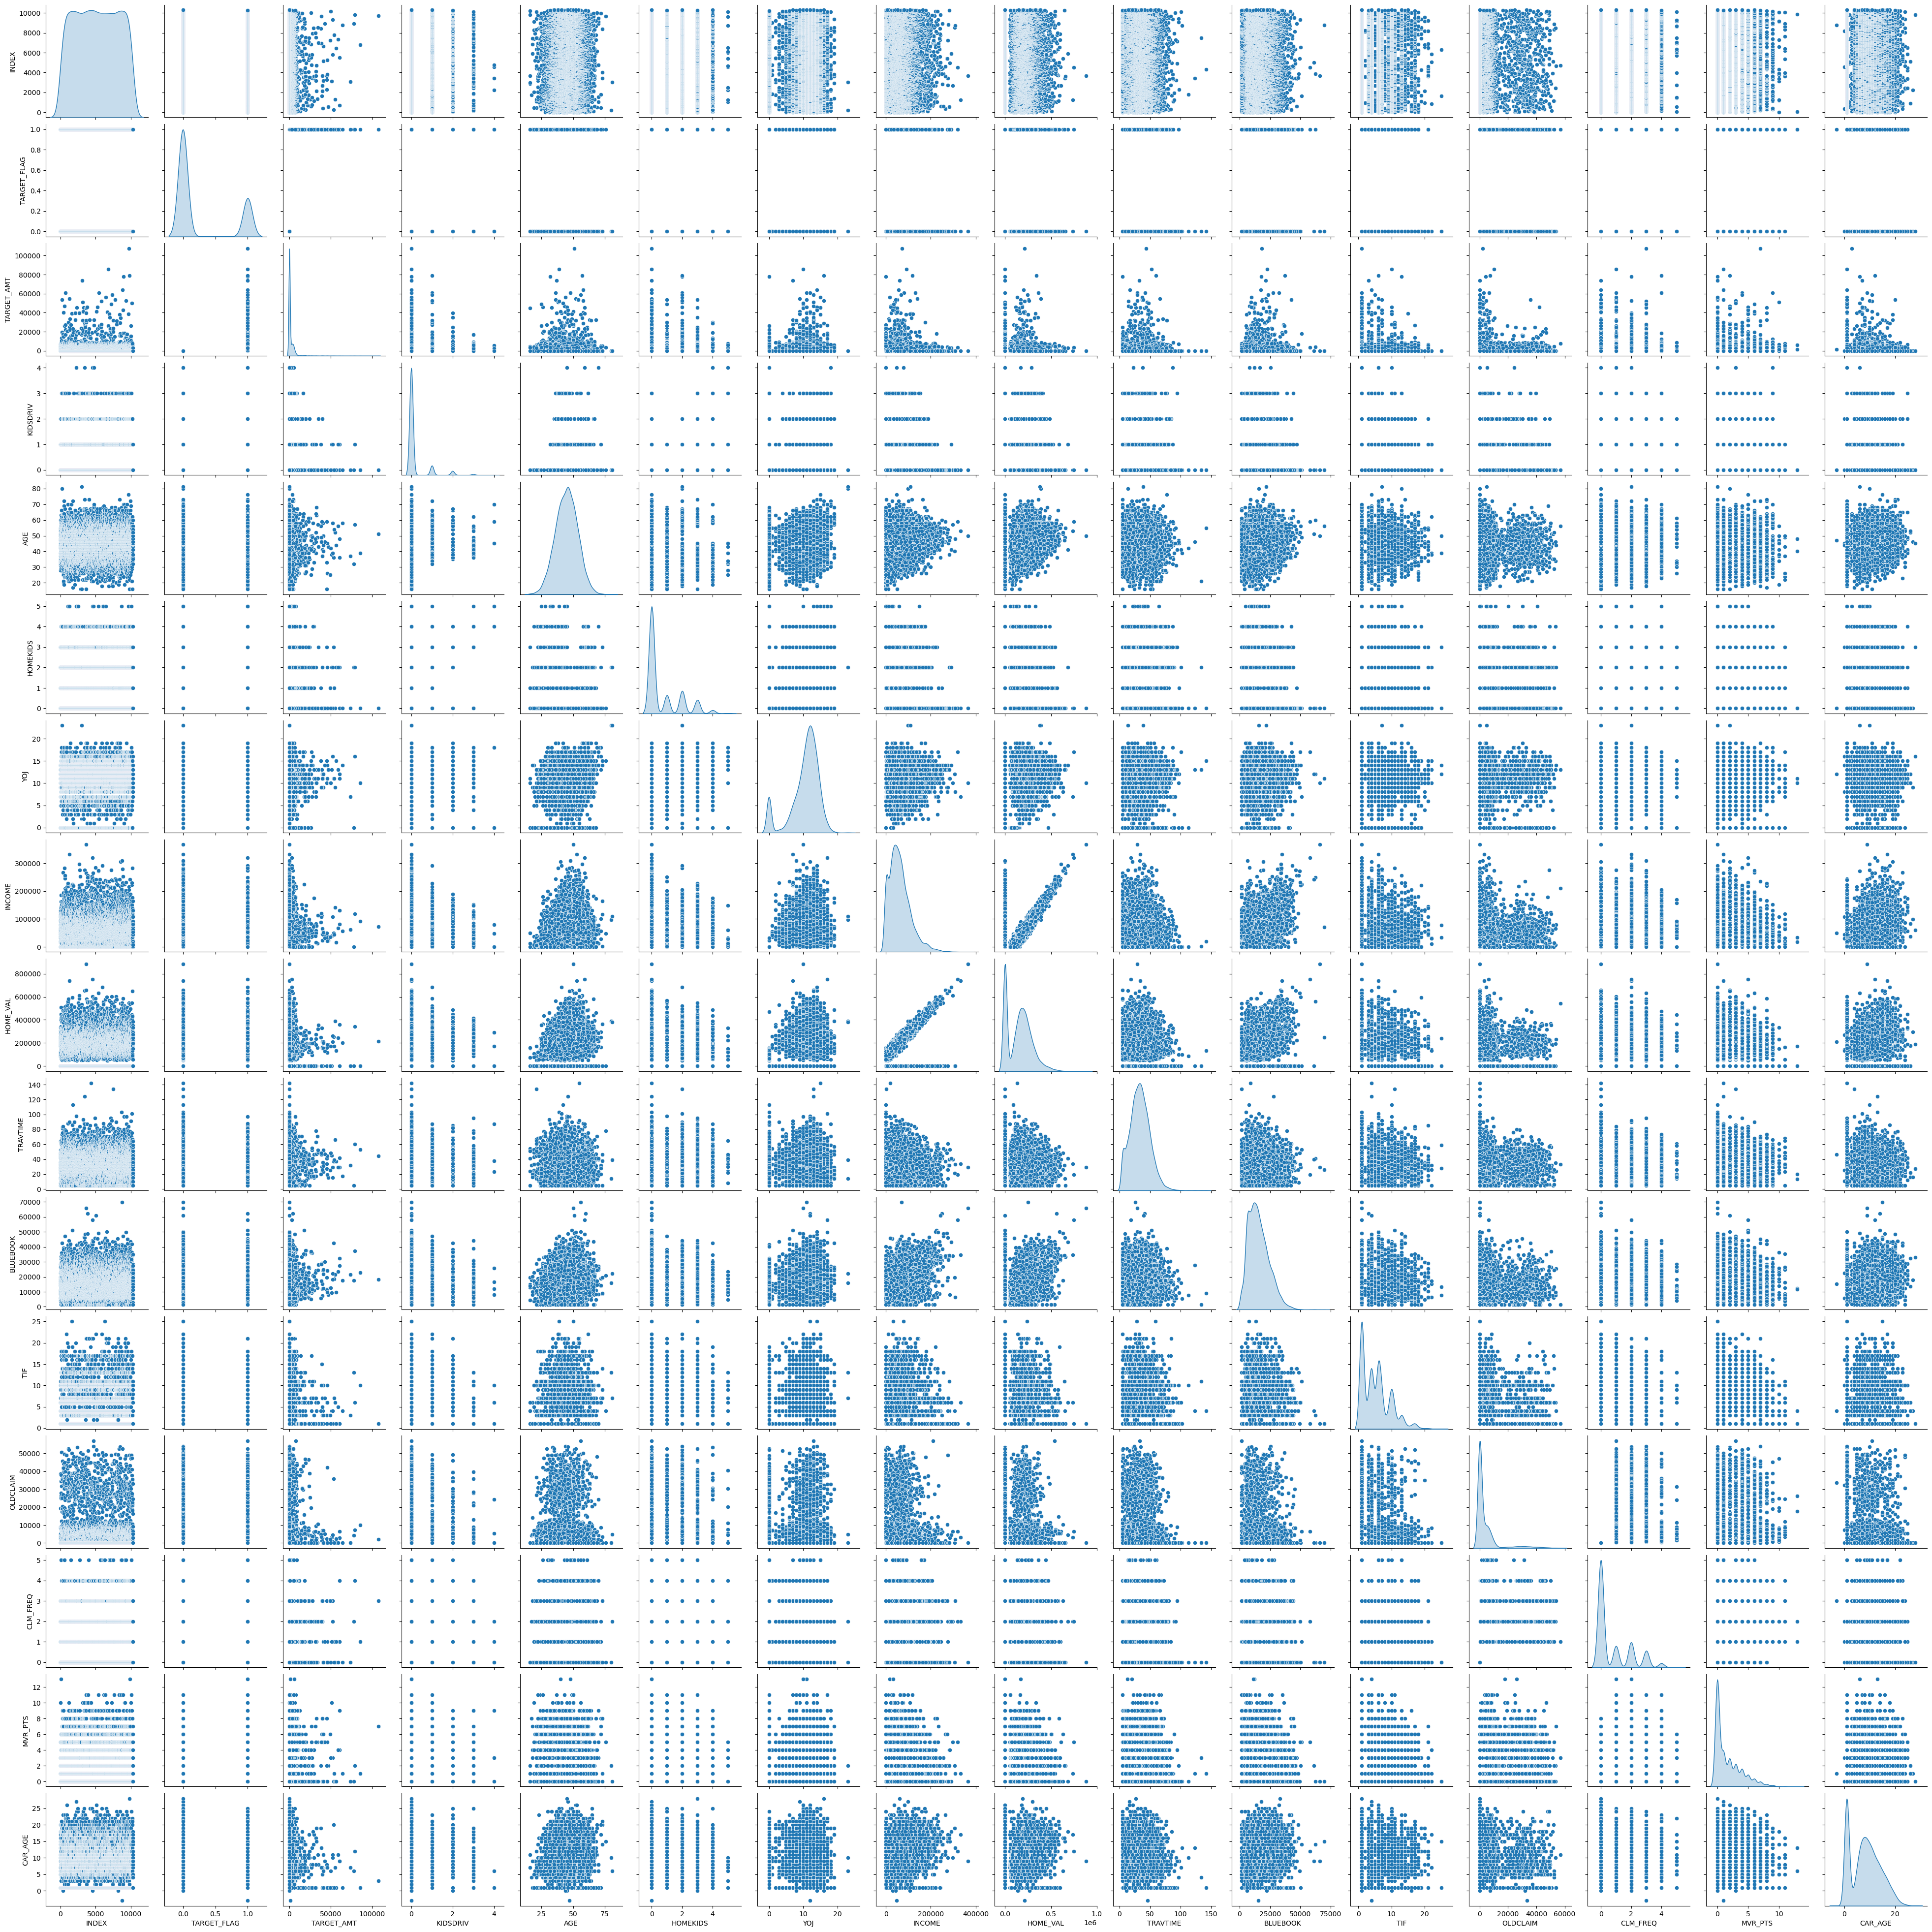

In [8]:
#now let's see some distributions and correlations of the variables. 
#Let's do some EDA.
sns.pairplot(auto, diag_kind="kde")

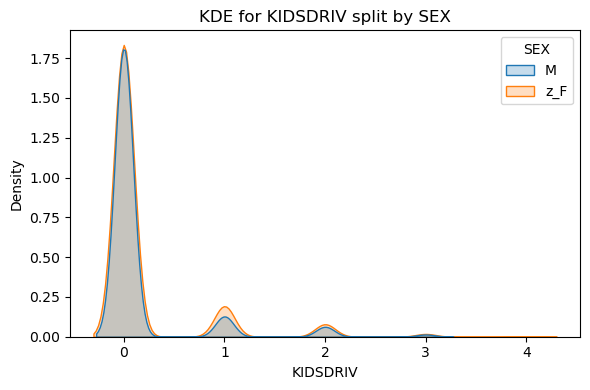

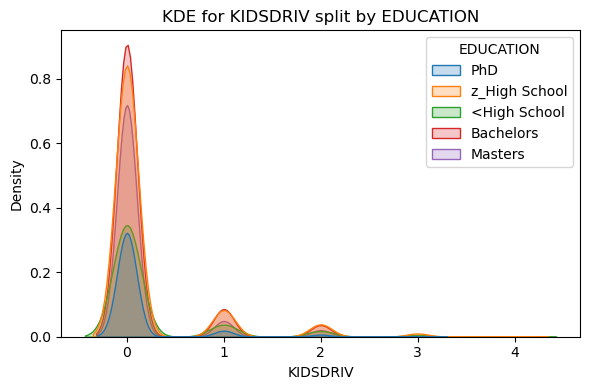

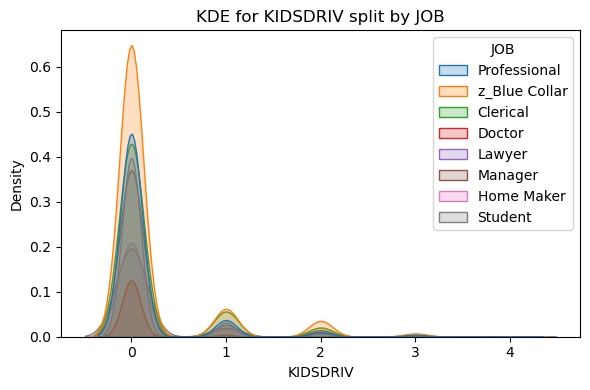

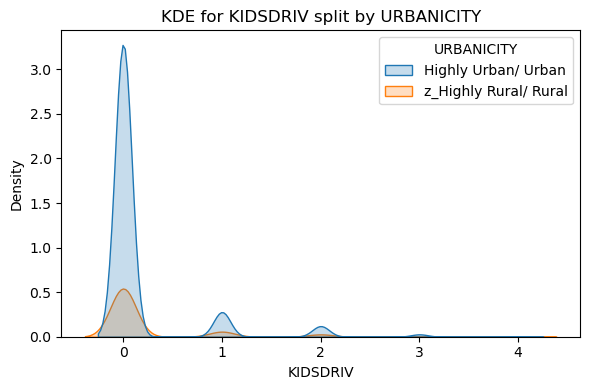

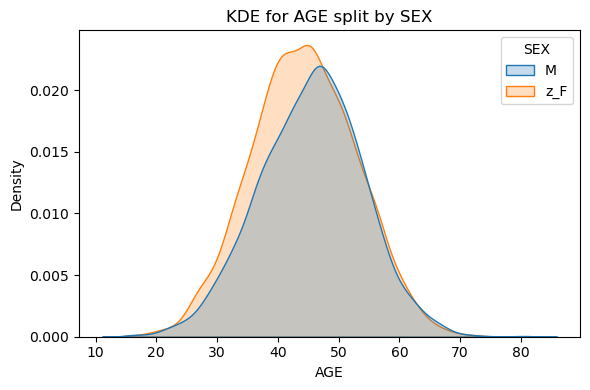

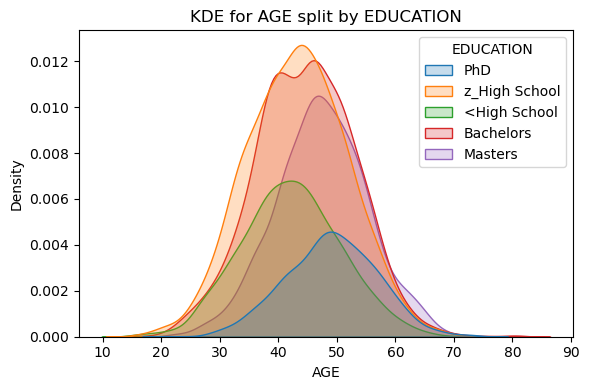

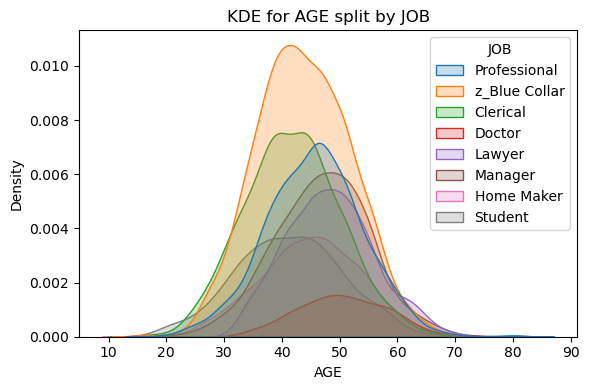

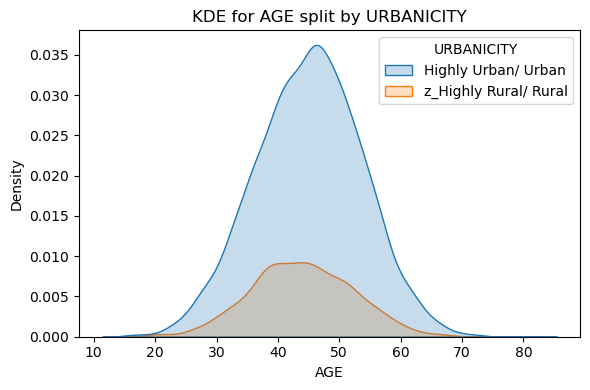

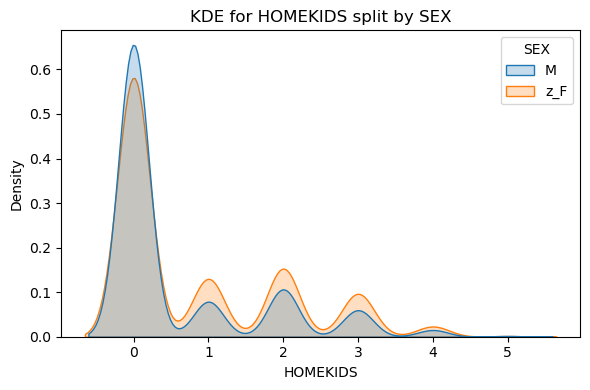

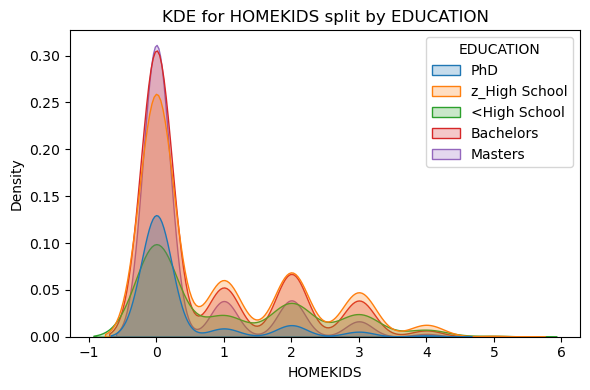

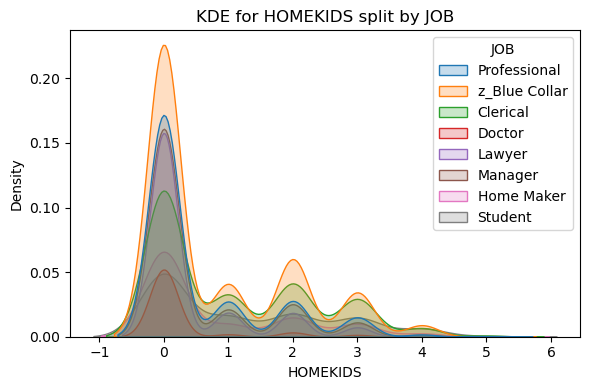

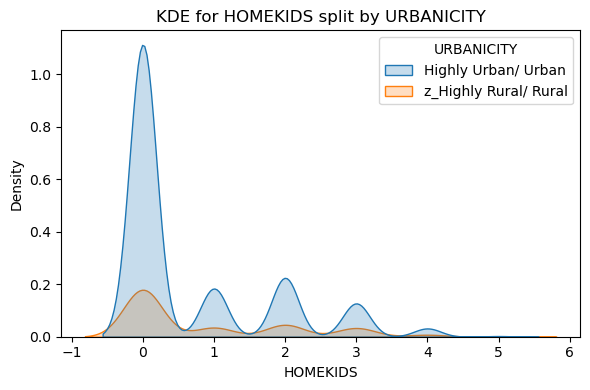

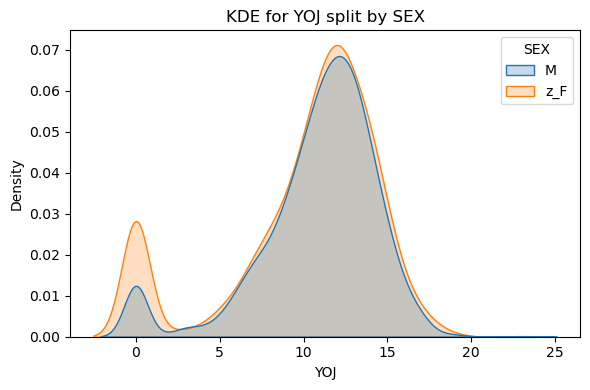

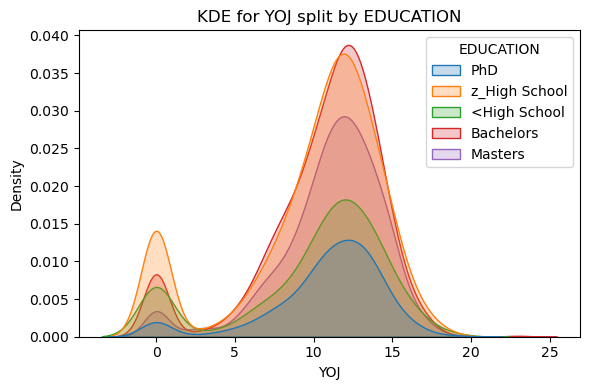

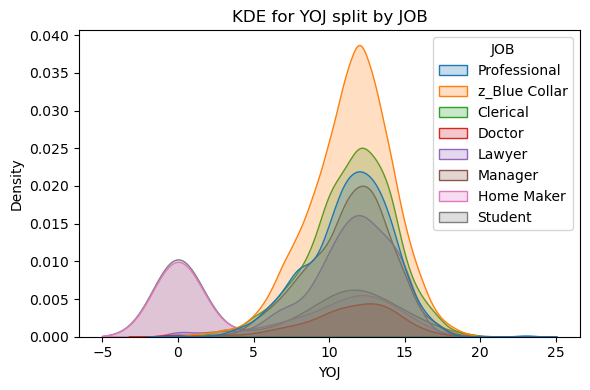

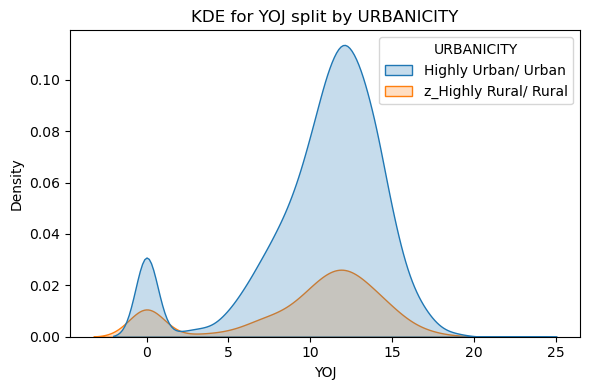

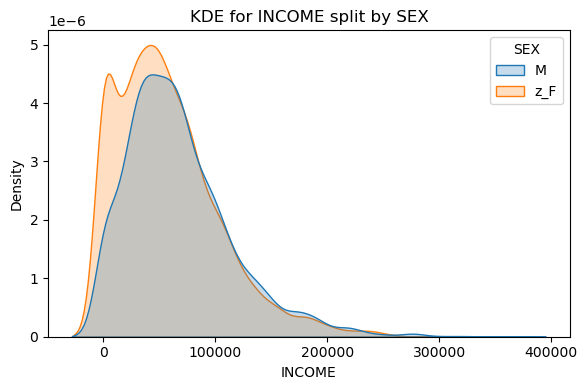

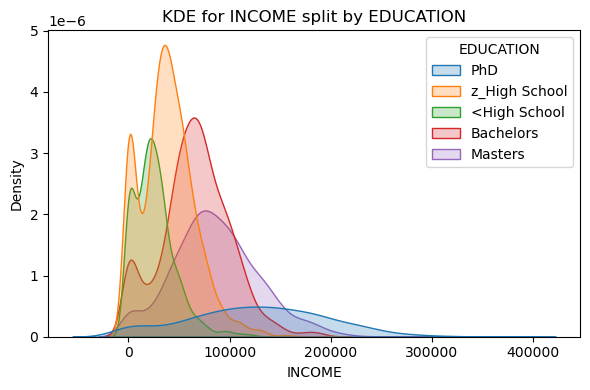

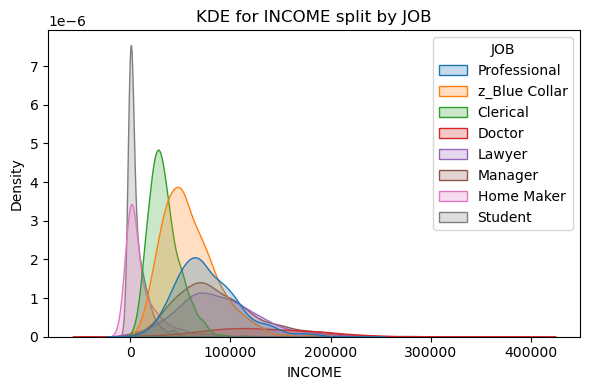

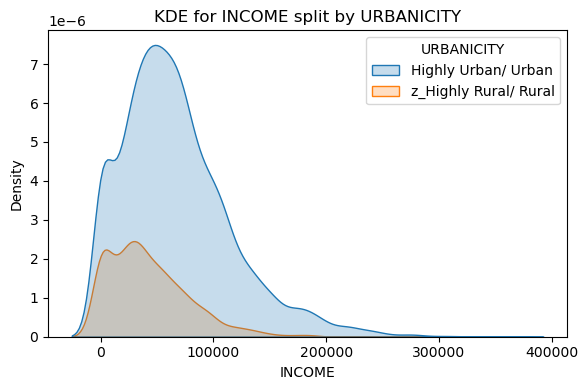

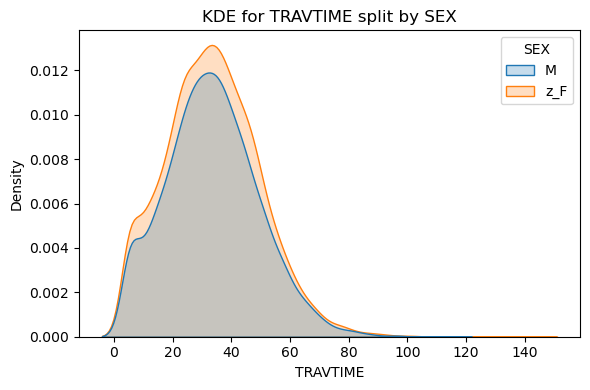

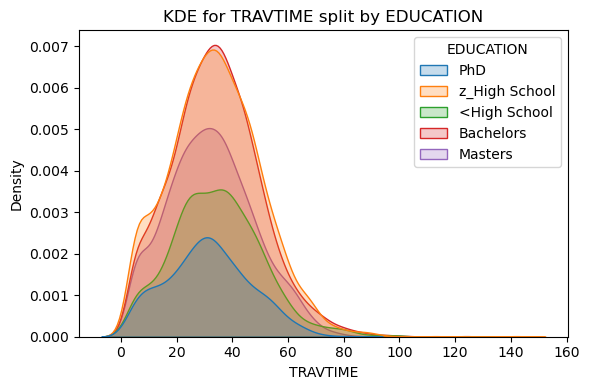

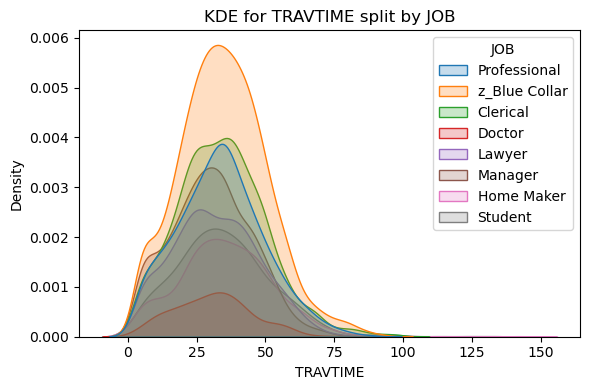

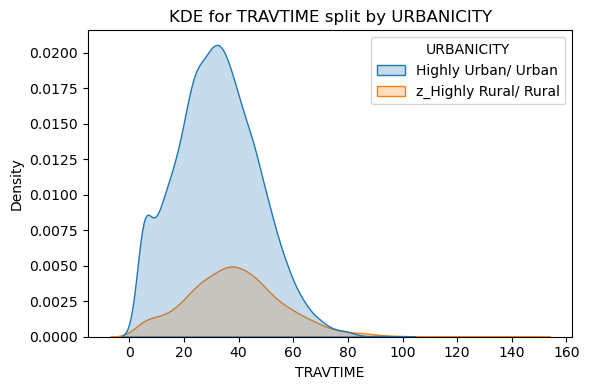

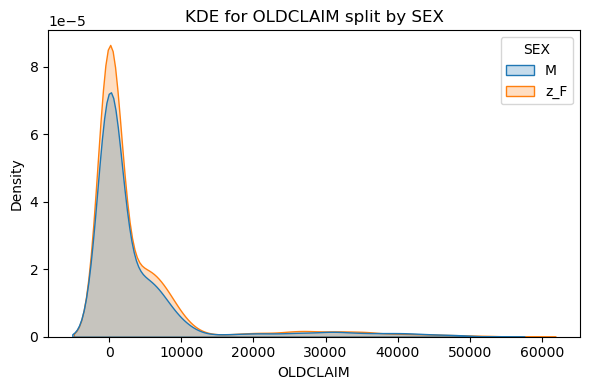

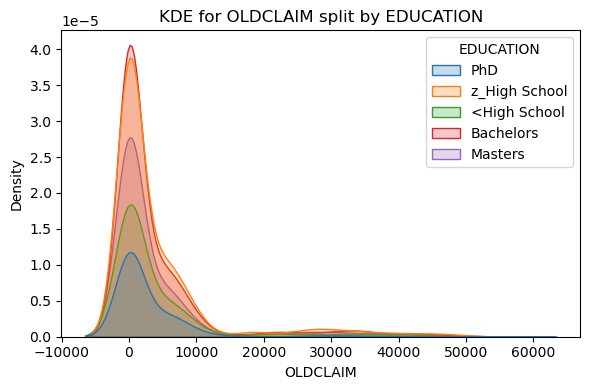

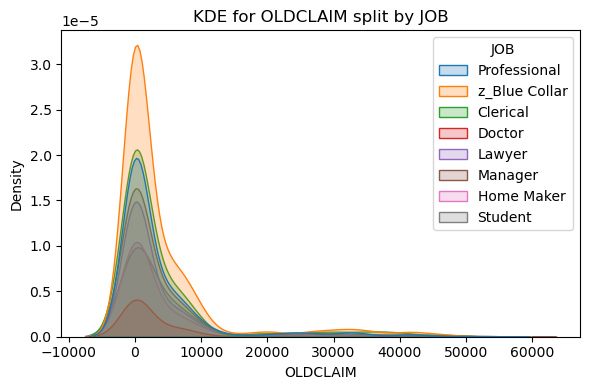

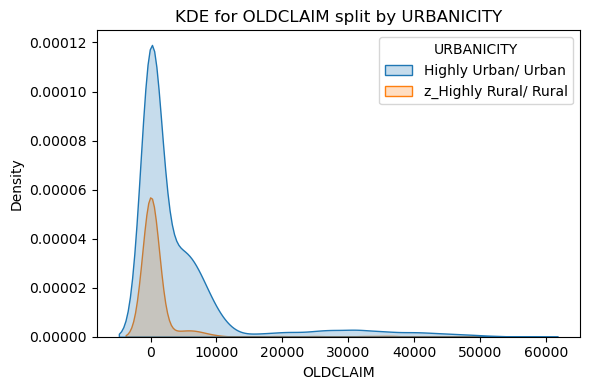

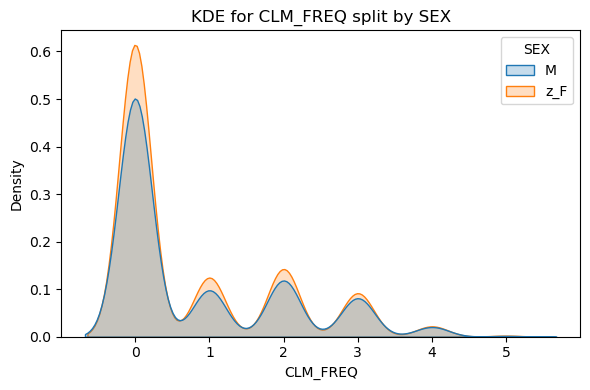

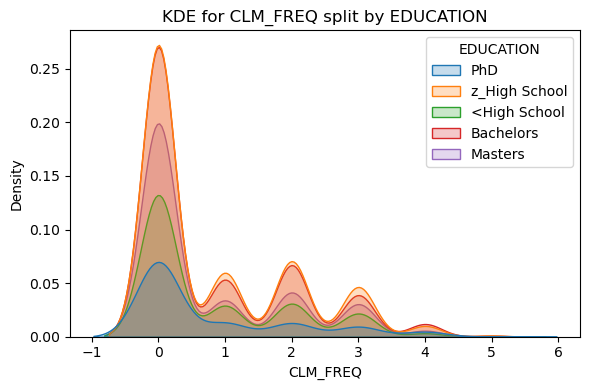

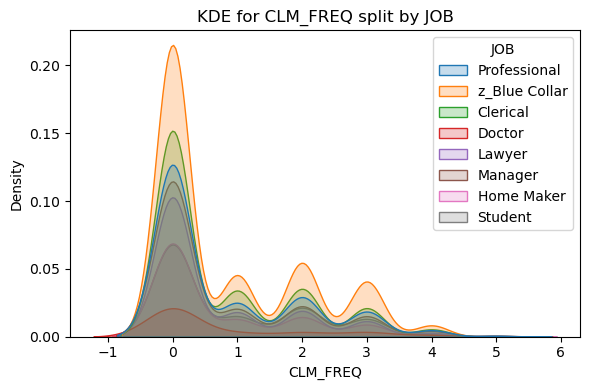

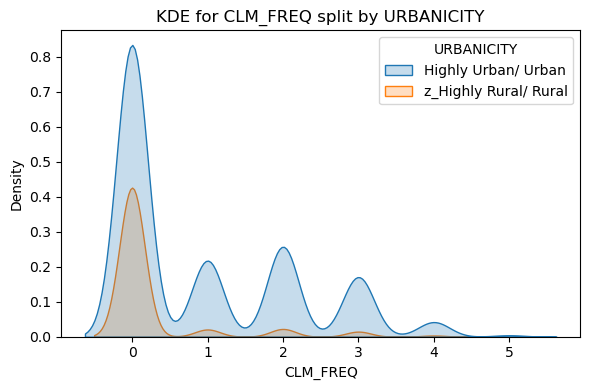

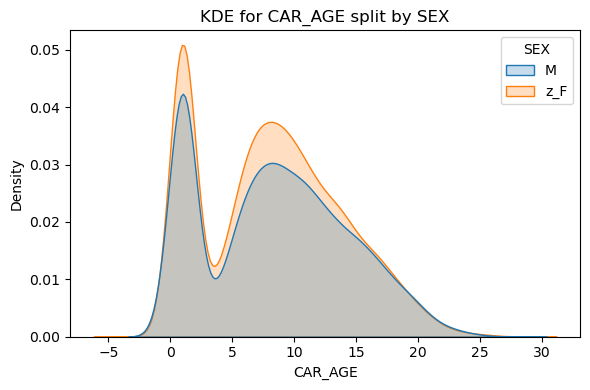

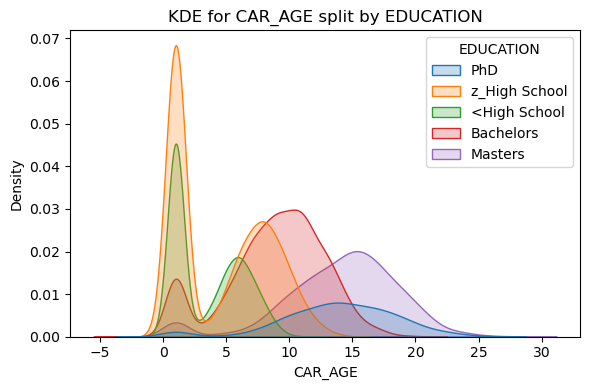

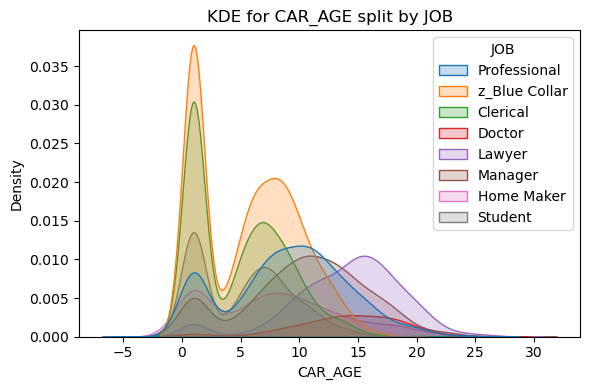

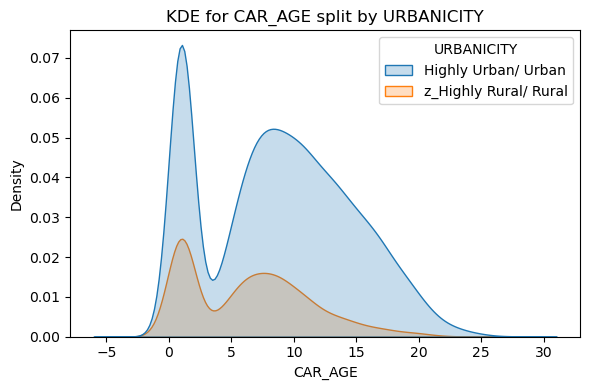

In [58]:
features = ['KIDSDRIV','AGE','HOMEKIDS','YOJ','INCOME','TRAVTIME','OLDCLAIM','CLM_FREQ','CAR_AGE']
hues = ['SEX','EDUCATION','JOB','URBANICITY']

for feature in features:
    for hue in hues:
        plt.figure(figsize=(6, 4))
        sns.kdeplot(data=auto, x=feature, hue=hue, fill=True)
        plt.title(f'KDE for {feature} split by {hue}')
        plt.tight_layout()
        plt.show()

<AxesSubplot: xlabel='SEX', ylabel='INCOME'>

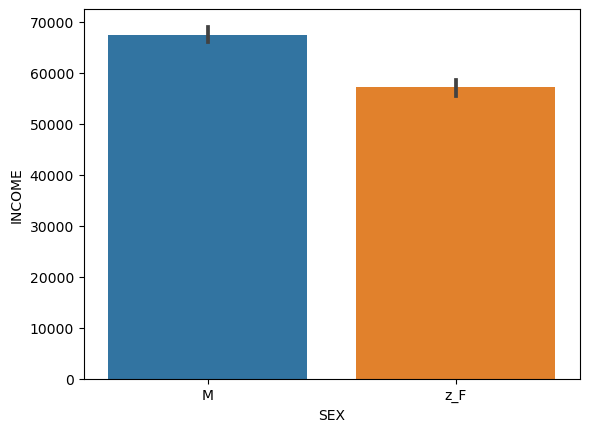

In [10]:
sns.barplot(data=auto, x='SEX', y='INCOME')

<AxesSubplot: xlabel='SEX', ylabel='TARGET_AMT'>

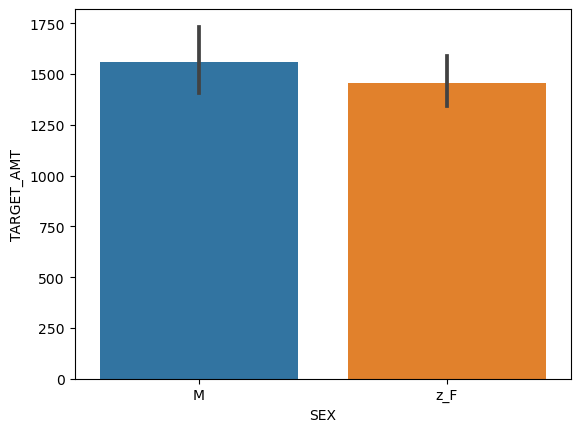

In [11]:
sns.barplot(data=auto, x='SEX', y='TARGET_AMT')

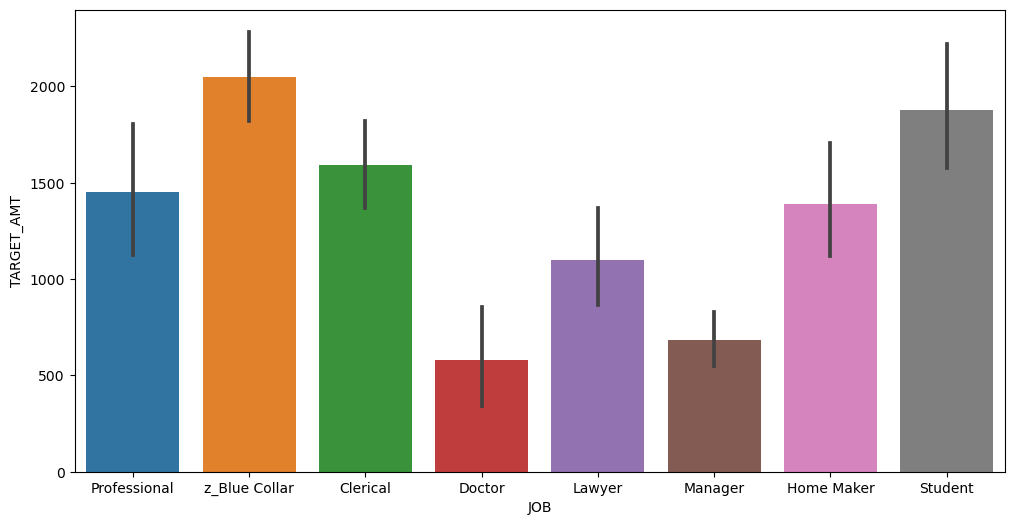

In [12]:
plt.figure(figsize=(12, 6))  # create figure with desired size first
sns.barplot(data=auto, x='JOB', y='TARGET_AMT')
plt.show()

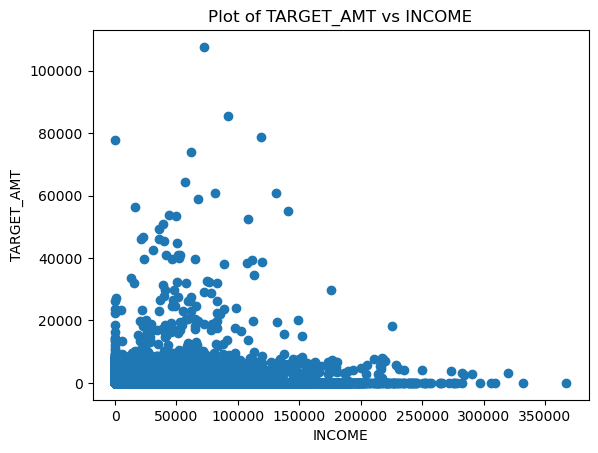

In [13]:
plt.plot(auto['INCOME'], auto['TARGET_AMT'], marker='o', linestyle='')
plt.xlabel('INCOME')
plt.ylabel('TARGET_AMT')
plt.title('Plot of TARGET_AMT vs INCOME')
plt.show()

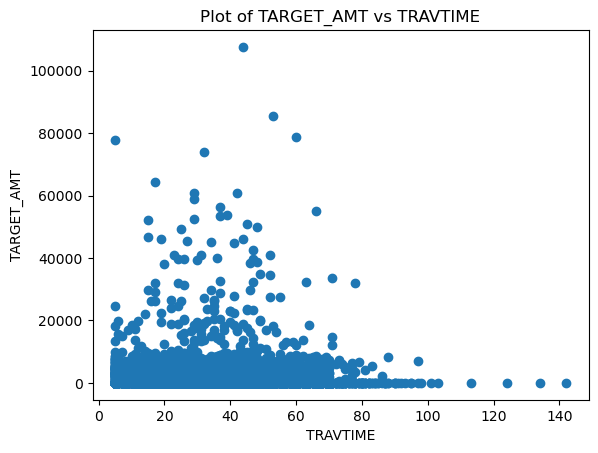

In [14]:
plt.plot(auto['TRAVTIME'], auto['TARGET_AMT'], marker='o', linestyle='')
plt.xlabel('TRAVTIME')
plt.ylabel('TARGET_AMT')
plt.title('Plot of TARGET_AMT vs TRAVTIME')
plt.show()

---------------------------------------------------------------------------------------------------------------
**STEP 4: CORRELATIONS**

The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.


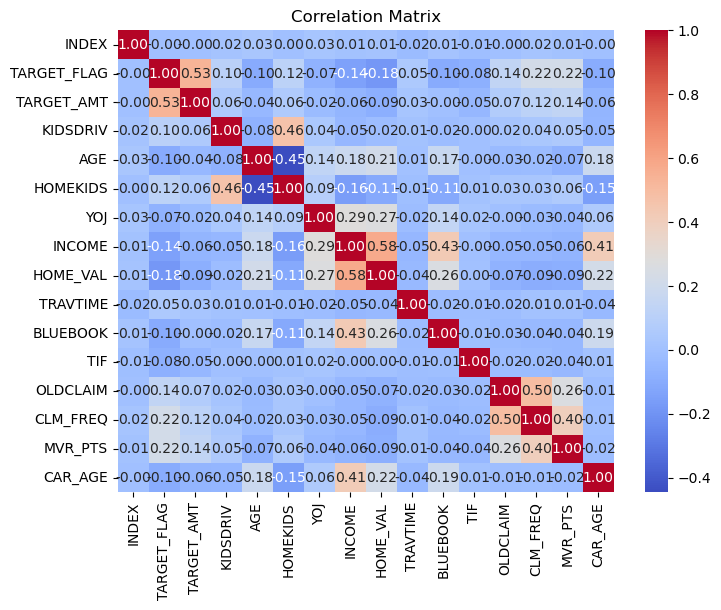

In [15]:
#let's see the correlation between the variables
corr_matrix = auto.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

What we can see from the heatmap is that there are very few correlated variables, which are:
- Homekids with Kidsdriv
- Homekids with Age
- Home_Val with Income
- Bluebook with Income
- YOJ with Income
- Car_Age with Income
- Clm_Freq with Oldclaim
- Clm_Freq with Mvr_Pts

From this we can consider to remove <h1 style="color: red; font-size: 12px;">HOMEKIDS</h1><h1 style="color: red; font-size: 12px;">HOME_VAL</h1><h1 style="color: red; font-size: 12px;">BLUEBOOK</h1><h1 style="color: red; font-size: 12px;">YOJ</h1><h1 style="color: red; font-size: 12px;">CAR_AGE</h1><h1 style="color: red; font-size: 12px;">MVR_PTS</h1>

Instead is obvious that CLM_FREQ and OLDCLAIM are correlated, since OLDCLAIM is valued whenever CLM_FREQ is >0, but I think it is better to consider both since the first works as a flag (have there been other claims in the past?) and the second works as an amount of how much the old claim has cost.

---------------------------------------------------------------------------------------------------------------
**STEP 5: MISSING VALUES**

Missing values can pose significant challenges in a data science project, especially for machine learning models that do not handle them natively. Therefore, it is essential to address missing data through appropriate imputation techniques. However, before imputing, it is important to analyze the extent and distribution of the missingness. Typically, if the percentage of missing values in a feature is below **5–10%**, imputation is considered reasonable; beyond that, the reliability of imputation may decrease, and other strategies (like feature removal or advanced modeling) might be needed. Additionally, understanding the mechanism behind the missing data is crucial. Data can be **MCAR** (Missing Completely at Random), where the missingness is unrelated to any values; **MAR** (Missing at Random), where the missingness is related to observed data but not the missing data itself; or **MNAR** (Missing Not at Random), where the missingness depends on the unobserved data. This distinction affects which imputation strategies are most appropriate.

In [16]:
#now let's see the missing values distribution
missing_counts = auto.isnull().sum()
print(missing_counts[missing_counts > 0])

missing_percent = auto.isnull().mean() * 100
print(missing_percent[missing_percent > 0])

AGE           6
YOJ         454
INCOME      445
HOME_VAL    464
JOB         526
CAR_AGE     510
dtype: int64
AGE         0.073520
YOJ         5.563044
INCOME      5.452763
HOME_VAL    5.685578
JOB         6.445289
CAR_AGE     6.249234
dtype: float64


In [17]:
#now let's reduce the dataframe to the only columns we want, due to correlation
auto_new = auto.drop(["HOME_VAL","BLUEBOOK","HOMEKIDS","CAR_AGE","MVR_PTS","YOJ"], axis=1)

#now let's see the missing values distribution
missing_counts = auto_new.isnull().sum()
print(missing_counts[missing_counts > 0])

missing_percent = auto_new.isnull().mean() * 100
print(missing_percent[missing_percent > 0])

AGE         6
INCOME    445
JOB       526
dtype: int64
AGE       0.073520
INCOME    5.452763
JOB       6.445289
dtype: float64


What we see is that in each feature, the percentage of missing values (0%, 5% and 6%) is in the acceptable range. It means that we can proceed with imputation. For that, there are different methodologies and before it is highly recommended to see if the missing values are completely at random, at random or not at all. For this reason, let's see graphically how they're distributed.

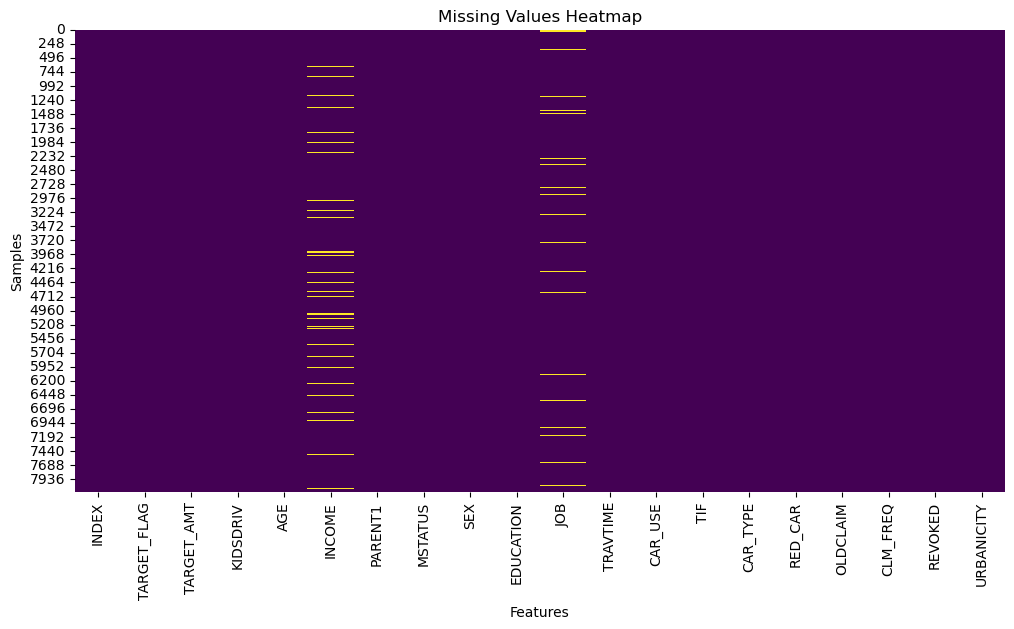

In [18]:
#graphics of missing values
plt.figure(figsize=(12, 6))
sns.heatmap(auto_new.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.xlabel("Features")
plt.ylabel("Samples")
plt.show()

It doesn't seem to be any kind of particular distribution. We can assume them to be at least MAR, therefore we can proceed with imputation.

In [19]:
#let's impute missing values. Now we'll do it in the easiest way (mean) but it would be better to further analyze the best method to use
from sklearn.impute import SimpleImputer

#for numerical variables the method could be the mean
imputer = SimpleImputer(strategy='mean')  # or 'median', 'most_frequent', 'constant'
auto_new[['AGE','INCOME']] = imputer.fit_transform(auto_new[['AGE','INCOME']])

#for the categorical variables the method could be the most frequent
imputer_cat = SimpleImputer(strategy='most_frequent')
auto_new[['JOB']] = imputer_cat.fit_transform(auto_new[['JOB']])

missing_percent = auto_new.isnull().mean() * 100
print(missing_percent[missing_percent > 0])

Series([], dtype: float64)


---------------------------------------------------------------------------------------------------------------
**STEP 6: DUMMIES**

In [20]:
#now we need to transform all the categorical variables into dummy ones
auto_new.dtypes
auto_new_dummy = pd.get_dummies(auto_new, columns=['PARENT1', 'MSTATUS','SEX','EDUCATION','JOB','CAR_USE','CAR_TYPE','RED_CAR','REVOKED','URBANICITY'], drop_first=True)

---------------------------------------------------------------------------------------------------------------
**STEP 7: CHOOSE THE MODEL**

For this project we can see that the target variables are two: TARGET_FLG and TARGET_AMT.
- TARGET_FLG could be either 0 or 1 -> it means that if we want to predict it, we would like to obtain with a high confidence, the probability to guess whether the record will be a claim or not.
- TARGET_AMT represents the cost of the claim -> predicting it means to understand which will be the cost of the claim. 

For what they represent, it is quite obvious that predicting TARGET_FLG is a classification problem and predicting TARGET_AMT is a regression one.

Nonetheless, in this picture there could be more ways to follow:
1) The first one is to predict both variables in parallel (PARALLEL MODEL).
2) The second one is to predict firstly TARGET_FLG and then TARGET_AMT (SEQUENTIAL MODEL).
3) The third one is to predict firstly TARGET_FLG and then TARGET_AMT but just for the supposed claims obtained from the previous step (SEQUENTIAL MODEL but reduced to a subset).


The best way to approach this is to try all the choises and compare their metrics amongst each other, but it would take too much time for this purpose. For this reason, we are going to try just no. 3.
This because I think that the classification problem is harder than the regression one, so a better classification will lead to a better forecasting of costs as well.

The questions now are:
1) Which methods to choose from for the classification and the regression?
2) Which metrics to evaluate them?

What we haven't considered yet is if the dataset is balanced or not. Since it talks about claims, I expect it not to be balanced. If this assumption is correct, then it's better to use models more robust than a simple Logistic Regression for the classification, such as a *Gradient Boosting Classification* model, an *SVM* one or either a *Naive Bayesian* one.

In [21]:
#Let's see if the dataframe is skewed.
target_flag_1_percent = (auto["TARGET_FLAG"].sum()/auto["TARGET_FLAG"].count())*100
print(target_flag_1_percent)

26.38157088592084


The assumption was correct! **Only 26% of the dataframe are claims**. This means that the class 1 is less represented and it is more important to understand whether there will be a claim, since if there is a claim there is a cost and the risks to take by the company are higher. It means that class 1 is also more important.

Recap: class 1 is less representend (skewed dataframe -> different choise of the model) and class 1 is more important (this will be essential for the choise of the metric to evaluate the model)

It is important to see also how TARGET_AMT is distributed. So let's do it and then jump into modeling

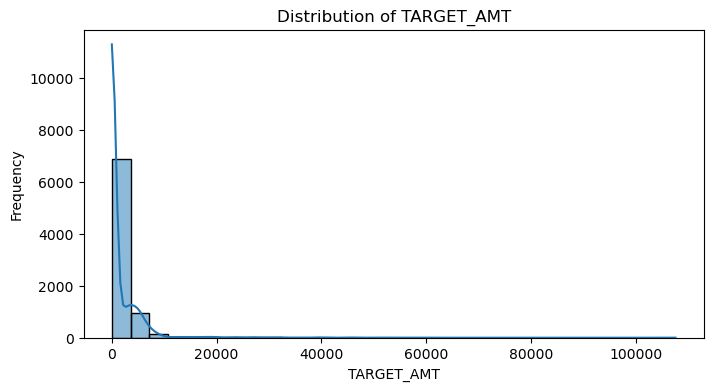

In [22]:
plt.figure(figsize=(8, 4))
sns.histplot(auto_new_dummy['TARGET_AMT'], kde=True, bins=30)
plt.title("Distribution of TARGET_AMT")
plt.xlabel("TARGET_AMT")
plt.ylabel("Frequency")
plt.show()

The graph is really uncomfortable to see. Let's try to transform the amounts with a log-scale in order to make the values less skewed and picked

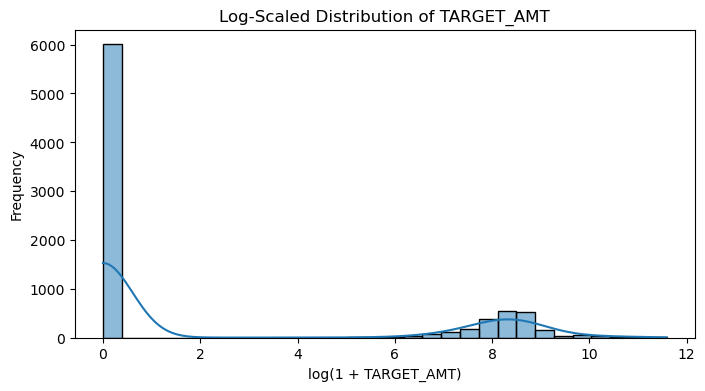

In [23]:
plt.figure(figsize=(8, 4))
sns.histplot(np.log1p(auto_new_dummy['TARGET_AMT']), kde=True, bins=30)
plt.title("Log-Scaled Distribution of TARGET_AMT")
plt.xlabel("log(1 + TARGET_AMT)")
plt.ylabel("Frequency")
plt.show()

Way better. What we see is that there are lots of values near to 0 but also some (not too many) that are higher. They're could be considered as outliers, but to do so it is better to calculate the IQR and see where these records are located with respect to it.
This means that a simple Linear Regression maybe is not the best choise. In fact, we'll try a more robust model such as a *Gradient Boosting Regression* model.

In [24]:
#now that we had done EDA and imputed all the missing values, we're ready to do the hard work!
from sklearn.model_selection import train_test_split

#split the dataset into regressor and target variables
X=auto_new_dummy.drop(["TARGET_FLAG","TARGET_AMT"], axis=1)
y_class=auto_new_dummy["TARGET_FLAG"]
y_reg=auto_new_dummy["TARGET_AMT"]

#split the datasets in train and test ones
X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = train_test_split(X, y_class, y_reg, test_size=0.2, random_state=42)

---------------------------------------------------------------------------------------------------------------
**STEP 8: IMPLEMENT THE MODEL**

Now that we have decided to go first with Gradient Boosting Classification and Regression, the question is: which hyperparameters do I have to choose?
For this, we are going to implement the model using Grid Search as well, in order to optimize the choise amongst a set of values decided a priori (the problem has not been actually solved, just moved: which set of a priori values do I have to choose? But let's assume that the choise of these sets is reasonable).

-----------------------------------------**CLASSIFICATION PROBLEM**------------------------------------------------------

In [25]:
# Step 1: Predict TARGET_FLAG
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {'n_estimators': [50, 100, 200, 300],
             'learning_rate': [0.025, 0.05, 0.10, 0.5],
             'max_depth': [3, 5, 7, 10],
             'random_state': [42]}

gb_clf = GradientBoostingClassifier()

grid_search_class = GridSearchCV(gb_clf, param_grid, cv=5)
grid_search_class.fit(X_train, y_class_train)

print("The best hyperparameters for classification are:", grid_search_class.best_params_)
print("Best score:", grid_search_class.best_score_)

The best hyperparameters for classification are: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'random_state': 42}
Best score: 0.7863042955296216


In [26]:
#now we train the model with the best params that have been printed out
gb_clf_best = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gb_clf_best.fit(X_train, y_class_train)

#Let's make predictions
y_class_pred = gb_clf_best.predict(X_test)
y_class_prob = gb_clf_best.predict_proba(X_test)[:, 1]

Before going to regression problem and then the evaluation of the models, let's try out other classification models, in order to have something to compare.

Other choises could have been Support Vector Machine or Naive Bayes.

In [27]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, precision_recall_curve, auc

# Initialize SVM with class weights to handle imbalance
svm_clf = SVC(class_weight='balanced', probability=True, random_state=42)

# Train
svm_clf.fit(X_train, y_class_train)

# Predict probabilities and classes
y_pred_svm = svm_clf.predict(X_test)
y_proba_svm = svm_clf.predict_proba(X_test)[:, 1]  # Probability of positive class

In [28]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, precision_recall_curve, auc

# Initialize Gaussian Naive Bayes
nb_clf = GaussianNB()

# Train
nb_clf.fit(X_train, y_class_train)

# Predict probabilities and classes
y_pred_nb = nb_clf.predict(X_test)
y_proba_nb = nb_clf.predict_proba(X_test)[:, 1]

-----------------------------------------**REGRESSION PROBLEM**------------------------------------------------------

Also for the regression of the TARGET_AMT there could be more choises. As mentioned before we will forecast values just for records that have been predicted as claims.

In [29]:
#Let's predict TARGET_AMT only for flagged rows
flagged_indices = y_class_pred == 1
X_flagged = X_test[flagged_indices]
y_amt_flagged = y_reg_test[flagged_indices]

The models we are going to try are Gradient Boosting Regression, Linear Regression and boh

In [30]:
from sklearn.ensemble import GradientBoostingRegressor

#now let's look for the best params for the regression problem
param_grid = {'n_estimators': [50, 100, 200, 300],
             'learning_rate': [0.025, 0.05, 0.10, 0.5],
             'max_depth': [3, 5, 7, 10],
             'random_state': [42]}

gb_reg = GradientBoostingRegressor()

grid_search_reg = GridSearchCV(gb_reg, param_grid, cv=5)
grid_search_reg.fit(X_train, np.log1p(y_reg_train))

print("The best hyperparameters for regression are:", grid_search_reg.best_params_)
print("Best score:", grid_search_reg.best_score_)

The best hyperparameters for regression are: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'random_state': 42}
Best score: 0.23499320234139542


In [31]:
#now we train the model with the best params that have been printed out
gb_reg_best = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

#Let's make predictions
gb_reg_best.fit(X_train, np.log1p(y_reg_train))
y_pred_log = gb_reg_best.predict(X_flagged)
y_amt_pred = np.expm1(y_pred_log)

In [35]:
#Let's try Linear Regression as well
from sklearn.linear_model import LinearRegression

linear = LinearRegression()
linear.fit(X_train, np.log1p(y_reg_train))

# Coefficiente angolare (slope) e intercetta (intercept)
coefficients = linear.coef_
for feature, coef in zip(X_train.columns, coefficients):
    print(f"{feature}: {coef}")

print(f"Intercetta: {linear.intercept_}")

y_linear_pred = linear.predict(X_flagged)
y_amt_linear_pred = np.expm1(y_linear_pred)

INDEX: 5.023713680316923e-06
KIDSDRIV: 0.5999546909129111
AGE: -0.009919653705664912
INCOME: -6.39249808494605e-06
TRAVTIME: 0.016541826194517738
TIF: -0.06607745502295018
OLDCLAIM: -1.7808073418540978e-05
CLM_FREQ: 0.4033940435718548
PARENT1_Yes: 0.6532889692553174
MSTATUS_z_No: 0.7900134690934232
SEX_z_F: -0.27993310566026647
EDUCATION_Bachelors: -0.48228322778317423
EDUCATION_Masters: -0.4877018814350594
EDUCATION_PhD: -0.47769683579971906
EDUCATION_z_High School: 0.13052473192914796
JOB_Doctor: -0.6229933496958843
JOB_Home Maker: 0.1302196477387133
JOB_Lawyer: -0.09418475665643934
JOB_Manager: -1.1042796290885668
JOB_Professional: -0.14433740623192592
JOB_Student: 0.11126871356558168
JOB_z_Blue Collar: -0.06238104423443192
CAR_USE_Private: -1.0280355756403952
CAR_TYPE_Panel Truck: 0.03882298356267278
CAR_TYPE_Pickup: 0.7076274994657414
CAR_TYPE_Sports Car: 1.3783664568578955
CAR_TYPE_Van: 0.5554852375618976
CAR_TYPE_z_SUV: 1.0709005931182958
RED_CAR_yes: -0.06780725735231082
REVOKE

---------------------------------------------------------------------------------------------------------------
**STEP 9: EVALUATE THE MODELS**

Evaluating machine learning models requires selecting the right metrics that align with the problem and data characteristics. Common metrics include **accuracy**, which measures the overall correctness of the model, and **precision**, **recall**, and **F1-score**, which offer deeper insight into classification performance—especially for binary tasks. Precision reflects how many of the predicted positives are true positives, while recall captures how many actual positives were correctly identified. The F1-score balances precision and recall, making it useful when both false positives and false negatives matter. In imbalanced datasets, where one class dominates, accuracy can be misleading. For such cases, metrics like **ROC AUC**, **PR AUC** (Precision-Recall AUC) become more informative. If a specific class is more important (such as detecting fraud or disease) it's essential to optimize for recall or precision on that class, depending on whether false negatives or false positives are more costly.

Classification Report for Gradient Boosting:
               precision    recall  f1-score   support

           0       0.81      0.93      0.86      1189
           1       0.69      0.40      0.51       444

    accuracy                           0.79      1633
   macro avg       0.75      0.67      0.69      1633
weighted avg       0.77      0.79      0.77      1633

AUC Score: 0.8197345789860508


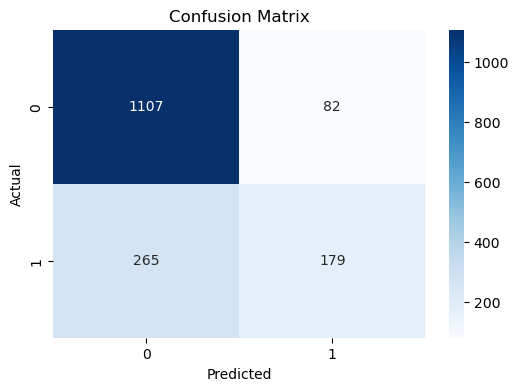

SVM Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.59      0.68      1189
           1       0.36      0.62      0.46       444

    accuracy                           0.60      1633
   macro avg       0.59      0.61      0.57      1633
weighted avg       0.69      0.60      0.62      1633

SVM PR-AUC: 0.389


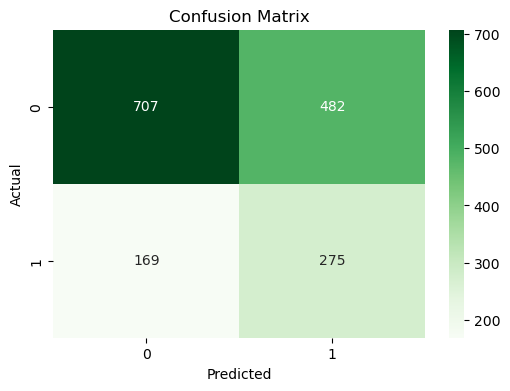

Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.94      0.83      1189
           1       0.48      0.15      0.23       444

    accuracy                           0.72      1633
   macro avg       0.61      0.54      0.53      1633
weighted avg       0.67      0.72      0.67      1633

Naive Bayes PR-AUC: 0.431


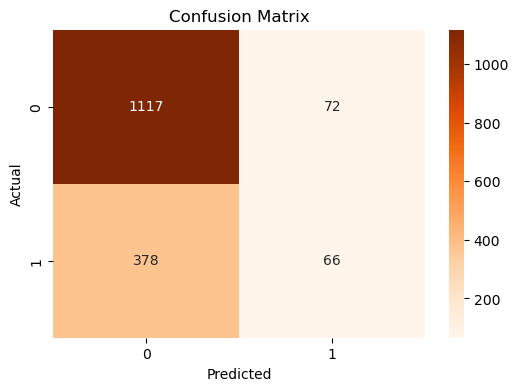

In [36]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, mean_squared_error, mean_absolute_error

#Let's evaluate the Gradient Boosting model
print("Classification Report for Gradient Boosting:\n", classification_report(y_class_test, y_class_pred))
print("AUC Score:", roc_auc_score(y_class_test, y_class_prob))

#Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_class_test, y_class_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


#Let's evaluate the SVM model
print("SVM Classification Report:\n", classification_report(y_class_test, y_pred_svm))

# Compute PR-AUC
precision_svm, recall_svm, _ = precision_recall_curve(y_class_test, y_proba_svm)
pr_auc_svm = auc(recall_svm, precision_svm)
print(f"SVM PR-AUC: {pr_auc_svm:.3f}")

#Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_class_test, y_pred_svm), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#Let's evaluate the Naive Bayes model
print("Naive Bayes Classification Report:\n", classification_report(y_class_test, y_pred_nb))

# Compute PR-AUC
precision_nb, recall_nb, _ = precision_recall_curve(y_class_test, y_proba_nb)
pr_auc_nb = auc(recall_nb, precision_nb)
print(f"Naive Bayes PR-AUC: {pr_auc_nb:.3f}")

#Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_class_test, y_pred_nb), annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

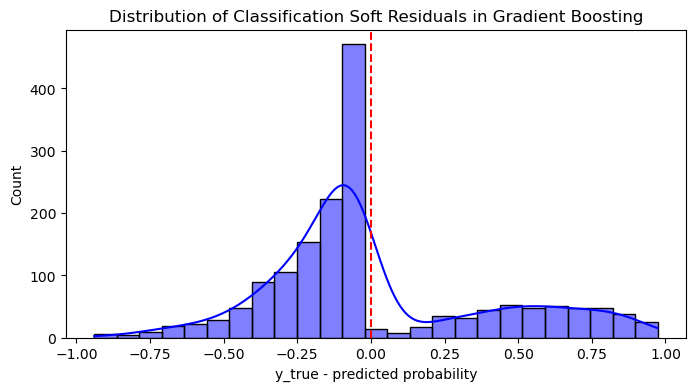

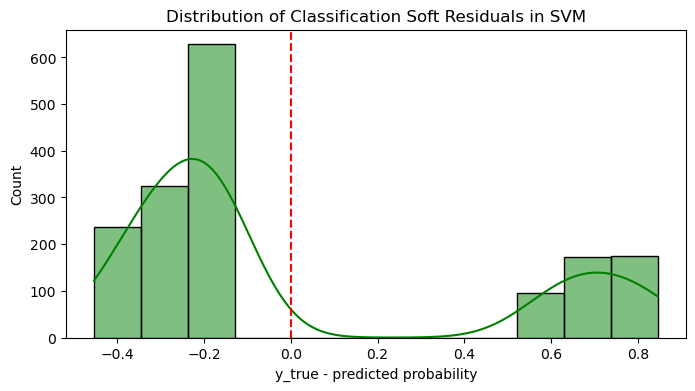

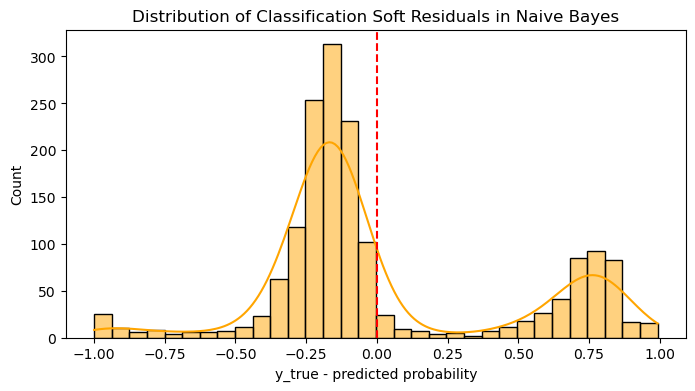

In [37]:
#Let's see the residuals for the classification problem
soft_residuals = y_class_test - y_class_prob
soft_residuals_svm = y_class_test - y_proba_svm
soft_residuals_nb = y_class_test - y_proba_nb

plt.figure(figsize=(8, 4))
sns.histplot(soft_residuals, kde=True, color='blue')
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribution of Classification Soft Residuals in Gradient Boosting")
plt.xlabel("y_true - predicted probability")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(soft_residuals_svm, kde=True, color='green')
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribution of Classification Soft Residuals in SVM")
plt.xlabel("y_true - predicted probability")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(soft_residuals_nb, kde=True, color='orange')
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribution of Classification Soft Residuals in Naive Bayes")
plt.xlabel("y_true - predicted probability")
plt.show()

In addition to standard metrics, the **Brier score** is useful when evaluating the quality of predicted probabilities rather than hard class predictions. It **measures the mean squared difference between predicted probabilities and the actual binary outcomes** (0 or 1), making it especially relevant for models where well-calibrated probabilities are important—such as in risk scoring, weather forecasting, or medical decision-making. A lower Brier score indicates better probabilistic accuracy. Unlike accuracy or F1-score, the Brier score rewards models that not only classify correctly but are also confident and calibrated in their predictions. However, it is not ideal for highly imbalanced datasets, as it can be dominated by the majority class unless adjustments or stratified evaluations are made. By the way, let's try it and see what value we obtain.

In [38]:
#https://en.wikipedia.org/wiki/Brier_score
#https://scikit-learn.org/stable/modules/generated/sklearn.metrics.brier_score_loss.html
from sklearn.metrics import brier_score_loss

BS_gbc = brier_score_loss(y_class_test, y_class_prob)
BS_svm = brier_score_loss(y_class_test, y_proba_svm)
BS_nb = brier_score_loss(y_class_test, y_proba_nb)

print(f"Gradient Boosting Classifier Brier Score: {BS_gbc:.2f}")
print(f"SVM Brier Score: {BS_svm:.2f}")
print(f"Naive Bayes Brier Score: {BS_nb:.2f}")

Gradient Boosting Classifier Brier Score: 0.15
SVM Brier Score: 0.19
Naive Bayes Brier Score: 0.19


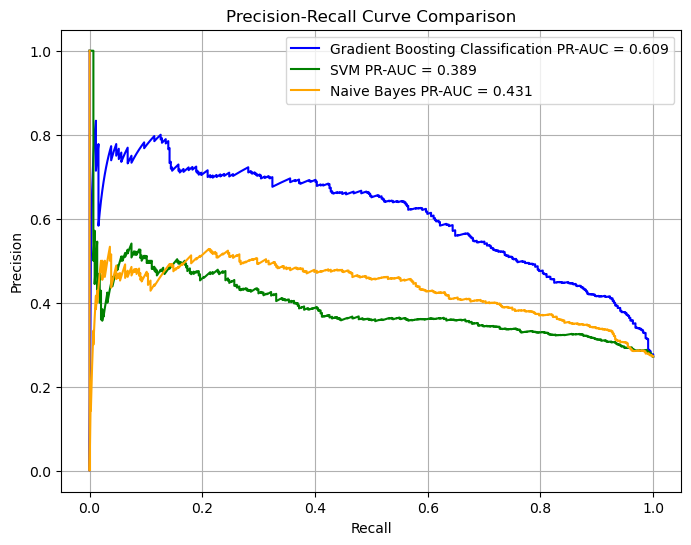

In [40]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_class_test, y_class_prob)
pr_auc = average_precision_score(y_class_test, y_class_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Gradient Boosting Classification PR-AUC = {pr_auc:.3f}', color='blue')
plt.plot(recall_svm, precision_svm, 
         label=f'SVM PR-AUC = {pr_auc_svm:.3f}', color='green')
plt.plot(recall_nb, precision_nb, label=f'Naive Bayes PR-AUC = {pr_auc_nb:.3f}', color='orange')

plt.xlabel('Recall')

plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend(loc='best')
plt.grid(True)
plt.show()

What we can see is that our first model performs the best, but how good is it compared to random guessing?

The class 1 in our dataset consists of just the 26%; it means that the baseline PR AUC Score is 0.26. Gradient Boosting reached a score of 0.609 based on the previous graph, so it means that Gradient Boosting is more than 2x the baseline. This indicates that the model is capturing the positive class meaningfully and both precision and recall are better than random guessing.

Regarding the Brier Score, a similar reasoning could be done: the baseline score would be

            Baseline Brier = (1-0.26)^2 * 0.26 + (0 - 0.26)^2 * (1-0.26) ~ 0.19
 
And since 0.15<0.19, Gradient Boosting improves the baseline score! (and also the SVM and Naive Bayes models)

---------------------------------------------------------------------------------------------------------------
To calculate the residuals for the regression predictions, beacuse of the choice to forecast the values of costs just for the predicted flagged, we need to enlarge the size of y_amt_pred adding zero values and then we can compare the vector to the testing one. In general, for regression problems, what needs to be done is a plot of the reisduals and see if they're distributed randomly around the zero.

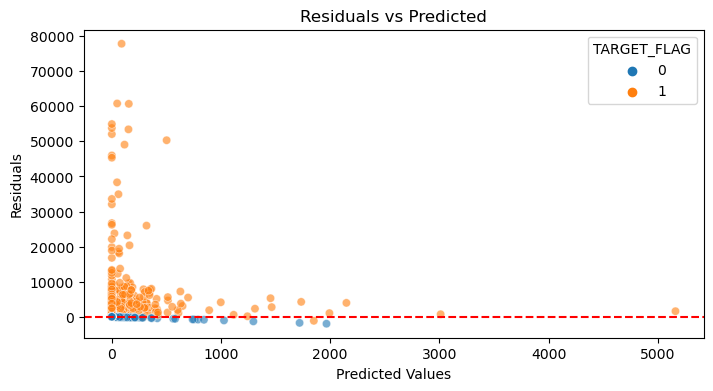

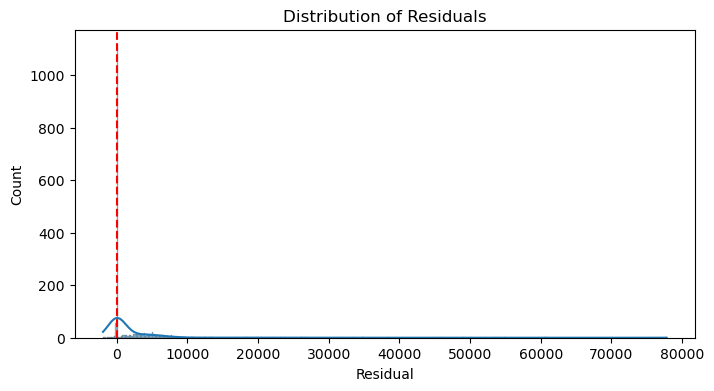

In [41]:
# Create a full-size array of zeros (or np.nan)
y_amt_pred_full = np.zeros_like(y_reg_test)
y_amt_pred_full[flagged_indices] = y_amt_pred

# Now the residuals match in shape
residuals = y_reg_test - y_amt_pred_full

# 1. Residuals vs predicted values
plt.figure(figsize=(8, 4))
sns.scatterplot(x=y_amt_pred_full, y=residuals, alpha=0.6, hue=y_class_test)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

# 2. Histogram of residuals
plt.figure(figsize=(8, 4))
sns.histplot(residuals, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.show()

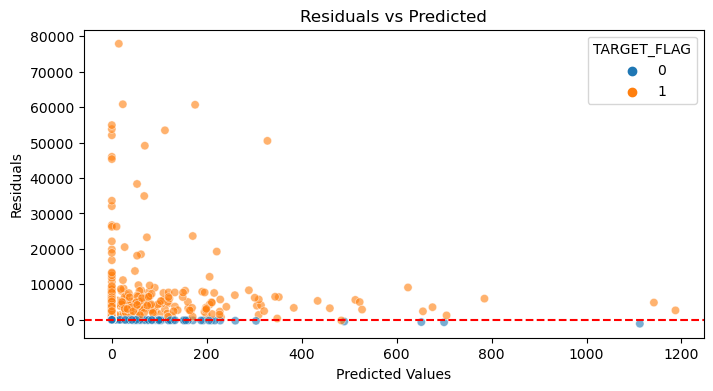

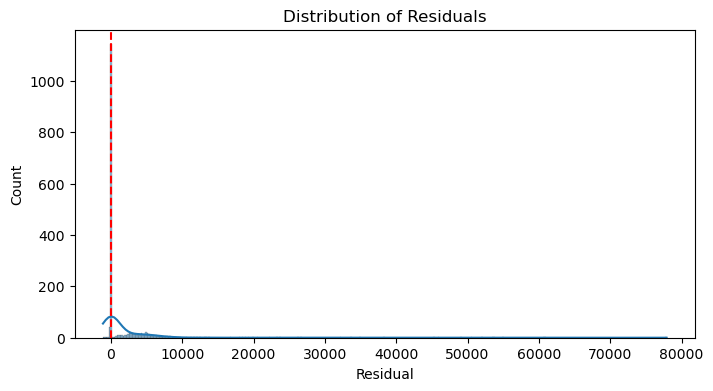

In [43]:
# Create a full-size array of zeros (or np.nan)
y_amt_pred_full_linear = np.zeros_like(y_reg_test)
y_amt_pred_full_linear[flagged_indices] = y_amt_linear_pred

# Now the residuals match in shape
residuals = y_reg_test - y_amt_pred_full_linear

# 1. Residuals vs predicted values
plt.figure(figsize=(8, 4))
sns.scatterplot(x=y_amt_pred_full_linear, y=residuals, alpha=0.6, hue=y_class_test)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

# 2. Histogram of residuals
plt.figure(figsize=(8, 4))
sns.histplot(residuals, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.show()

In [55]:
rmse_gbr = np.sqrt(mean_squared_error(y_reg_test, y_amt_pred_full, squared=False))
mae_gbr = mean_absolute_error(y_reg_test, y_amt_pred_full)

print(f"RMSE of Gradient Boosting Regression: {rmse_gbr:.2f}")
print(f"MAE of Gradient Boosting Regression: {mae_gbr:.2f}")

rmse_lr = np.sqrt(mean_squared_error(y_reg_test, y_amt_pred_full_linear, squared=False))
mae_l = mean_absolute_error(y_reg_test, y_amt_pred_full_linear)

print(f"RMSE of Linear Regression: {rmse_lr:.2f}")
print(f"MAE of Linear Regression: {mae_l:.2f}")

RMSE of Gradient Boosting Regression: 76.12
MAE of Gradient Boosting Regression: 1714.17
RMSE of Linear Regression: 76.19
MAE of Linear Regression: 1723.45


What we can see is that Gradient Boosting Regression did slightly better than a simple Linear Regression. Maybe an operation of fine tuning could have improved the model a little more, or maybe other approaches could have been tested. For the purpose of this project it's enough.

---------------------------------------------------------------------------------------------------------------
**CONCLUSIONS**

We've seen the entire workflow for a data science project, but of course different steps could be optimized.
For example, the imputation of the missing values may be done better, with more advanced methodologies (such as MICE techniques).

Moreover, the initial list of parameters to choose from for the Grid Search could have been selected with more accuracy, based on business knowledge or literature, and all the models could have been fine tuned.

Nonetheless, the main steps to follow are the mentioned ones and the approach is the one we've followed here.

References of literature, websites, libraries used must be collected as well.

In [39]:
#https://www.kaggle.com/code/marcinrutecki/best-techniques-and-metrics-for-imbalanced-dataset